# Machine Learning Model Training

This notebook trains and evaluates multiple machine learning models for crop recommendation.

Models:
- Logistic Regression (Baseline)
- Decision Tree Classifier
- Random Forest Classifier

Evaluation Metrics:
- Accuracy
- Confusion Matrix
- Classification Report

The best-performing model will be saved for future predictions.

## Load ML-Ready Dataset

The processed dataset created during feature engineering is loaded.

This dataset already contains:
- Encoded target values
- One-hot encoded categorical variables
- Scaled numerical features

No further preprocessing is required before training.

In [6]:
import pandas as pd

df = pd.read_csv("../data/processed/crop_ml_ready.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,rainfall_category_Low,rainfall_category_Medium,rainfall_category_High,temperature_category_Cool,temperature_category_Moderate,temperature_category_Hot,humidity_category_Low,humidity_category_Medium,humidity_category_High,season_type_Moderate,season_type_Summer,season_type_Winter,target
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361,False,False,True,False,True,False,False,False,True,True,False,False,20
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058,False,False,True,False,True,False,False,False,True,True,False,False,20
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066,False,False,True,False,True,False,False,False,True,True,False,False,20
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048,False,False,True,False,True,False,False,False,True,True,False,False,20
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373,False,False,True,False,True,False,False,False,True,True,False,False,20


## Defining Features and Target

The dataset is divided into:

- X (features): Soil and environmental conditions
- y (target): Encoded crop label

Machine learning models learn relationships between X and y.

In [7]:
X = df.drop("target", axis=1) #here we are dropping the target column to get the features

y = df["target"] #here we are selecting the target column to get the labels

print(X.shape)
print(y.shape)


(2200, 19)
(2200,)


## Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The model learns from the training data and is evaluated on unseen testing data.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #20% of the data will be used for testing and 80% for training
    random_state=42 #this is used to ensure that the split is reproducible, meaning that every time you run the code with the same random_state, you will get the same split of data
)

print("Training Samples:", len(X_train)) 
print("Testing Samples:", len(X_test))

Training Samples: 1760
Testing Samples: 440


# Logistic Regression (Baseline Model)

Logistic Regression is used as the baseline classification model.

Although the name contains "regression", it is actually a classification algorithm. Since this project contains 22 crop classes, multinomial logistic regression is automatically used.

The model learns relationships between soil/environmental conditions and crop labels, then predicts the most likely crop using Softmax probabilities.

In [9]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression ( #here we are creating an instance of the LogisticRegression class and assigning it to the variable log_model
    max_iter=5000, #here we are setting the maximum number of iterations for the solver to converge to a solution. This is important because if the solver does not converge, it will raise a warning and the model may not perform well. By setting max_iter to a higher value, we can ensure that the solver has enough iterations to find a solution.
    random_state=42 #here we are setting the random_state parameter to ensure that the results are reproducible. This means that every time you run the code with the same random_state, you will get the same results. This is important for debugging and comparing different models.
)

log_model.fit(X_train, y_train) #here it is fitting the logistic regression model to the training data. The fit method takes the features (X_train) and the labels (y_train) as input and trains the model to learn the relationship between the features and the labels. After fitting the model, it can be used to make predictions on new data or to evaluate its performance on the test set.

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [10]:
y_pred_log = log_model.predict(X_test) #here we are using the predict method of the logistic regression model to make predictions on the test set (X_test). The predict method takes the features of the test set as input and returns the predicted labels for those features. The predicted labels are stored in the variable y_pred_log.

print(y_pred_log[:10]) #here we are printing the first 10 predicted labels (in numbers not crop names) to see what the model has predicted for the test set. This can help us get an idea of how well the model is performing and whether the predictions make sense based on our understanding of the data.

[15 21 17 17  0 12  0 13 14 10]


In [11]:
from sklearn.metrics import accuracy_score #here accuracy_Score is a function

log_acc = accuracy_score( #here we are calculating the accuracy of the logistic regression model by comparing the true labels (y_test) with the predicted labels (y_pred_log). The accuracy_score function takes these two arrays as input and returns the proportion of correct predictions, which is stored in the variable log_acc.
    y_test,
    y_pred_log
)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.9613636363636363


## Accuracy Evaluation

Accuracy measures the percentage of correct predictions made by the model.

Accuracy = Correct Predictions / Total Predictions

Because all crop classes are balanced in this dataset, accuracy is an appropriate primary evaluation metric.

## Classification Report

The Classification Report evaluates model performance for each crop class using four metrics:

### Precision
Whenever the model predicts a specific crop, how often is that prediction correct?

Example:
If the model predicts Rice 100 times and 95 are actually Rice:

Precision = 95%

Higher precision means fewer false crop recommendations.

---

### Recall
Out of all actual occurrences of a crop, how many did the model successfully identify?

Example:
If there are 100 actual Rice samples and the model finds 90:

Recall = 90%

Higher recall means fewer missed crops.

---

### F1-Score
The harmonic mean of Precision and Recall.

It provides a balanced measure when both precision and recall are important.

Higher F1-score indicates better overall class performance.

---

### Support
The number of actual test samples belonging to a class.

Example:
Support = 23 means 23 testing samples existed for that crop.

In [30]:
mapping = pd.DataFrame({
    "Encoded_ID": range(len(crop_names)),
    "Crop_Name": crop_names
})

display(mapping)

,Encoded_ID,Crop_Name
0,0,apple
1,1,banana
2,2,blackgram
3,3,chickpea
4,4,coconut
5,5,coffee
6,6,cotton
7,7,grapes
8,8,jute
9,9,kidneybeans


In [ ]:
from sklearn.metrics import classification_report

# print(
#     classification_report( #here we are generating a classification report to evaluate the performance of the logistic regression model. The classification_report function takes the true labels (y_test) and the predicted labels (y_pred_log) as input and returns a report that includes precision, recall, f1-score, and support for each class. This report helps us understand how well the model is performing for each class and can highlight any issues with class imbalance or misclassification.
#         y_test,
#         y_pred_log
#     )
# )
print(
    classification_report(
        y_test,
        y_pred_log,
        target_names=crop_names
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.86      0.95      0.90        20
           3       1.00      1.00      1.00        26
           4       0.96      1.00      0.98        27
           5       1.00      1.00      1.00        17
           6       0.85      1.00      0.92        17
           7       1.00      1.00      1.00        14
           8       0.85      1.00      0.92        23
           9       0.91      1.00      0.95        20
          10       0.85      1.00      0.92        11
          11       1.00      0.81      0.89        21
          12       0.95      1.00      0.97        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      0.93      0.96        14
          17       1.00    

## Confusion Matrix

The confusion matrix provides a detailed breakdown of model predictions.

Rows represent the actual crop classes, while columns represent the predicted crop classes.

Interpretation:

- Values on the main diagonal represent correct predictions.
- Values outside the diagonal represent misclassifications.
- Larger diagonal values indicate better model performance.

For example:

If the Rice row and Rice column contain 16, it means 16 Rice samples were correctly classified as Rice.

If the Rice row and jute column contain 3, it means 3 Rice samples were incorrectly predicted as jute.

The confusion matrix helps identify exactly which crop classes are being confused by the model.

In [ ]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(
    y_test,
    y_pred_log
)

cm_df = pd.DataFrame(
    cm_log,
    index=crop_names,
    columns=crop_names
)

display(cm_df) 

,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
apple,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
banana,0,21,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
blackgram,0,0,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chickpea,0,0,0,26,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coconut,0,0,0,0,27,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coffee,0,0,0,0,0,17,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cotton,0,0,0,0,0,0,17,0,0,0,...,0,0,0,0,0,0,0,0,0,0
grapes,0,0,0,0,0,0,0,14,0,0,...,0,0,0,0,0,0,0,0,0,0
jute,0,0,0,0,0,0,0,0,23,0,...,0,0,0,0,0,0,0,0,0,0
kidneybeans,0,0,0,0,0,0,0,0,0,20,...,0,0,0,0,0,0,0,0,0,0


## Confusion Matrix Heatmap

The confusion matrix was visualized using a heatmap to make prediction patterns easier to interpret.

Darker cells indicate higher numbers of predictions.

A strong diagonal pattern indicates good classification performance because most predictions match the actual crop class.

Off-diagonal cells highlight classification errors and reveal which crops are occasionally confused with one another.

This visualization provides a quick summary of model strengths and weaknesses across all crop classes.

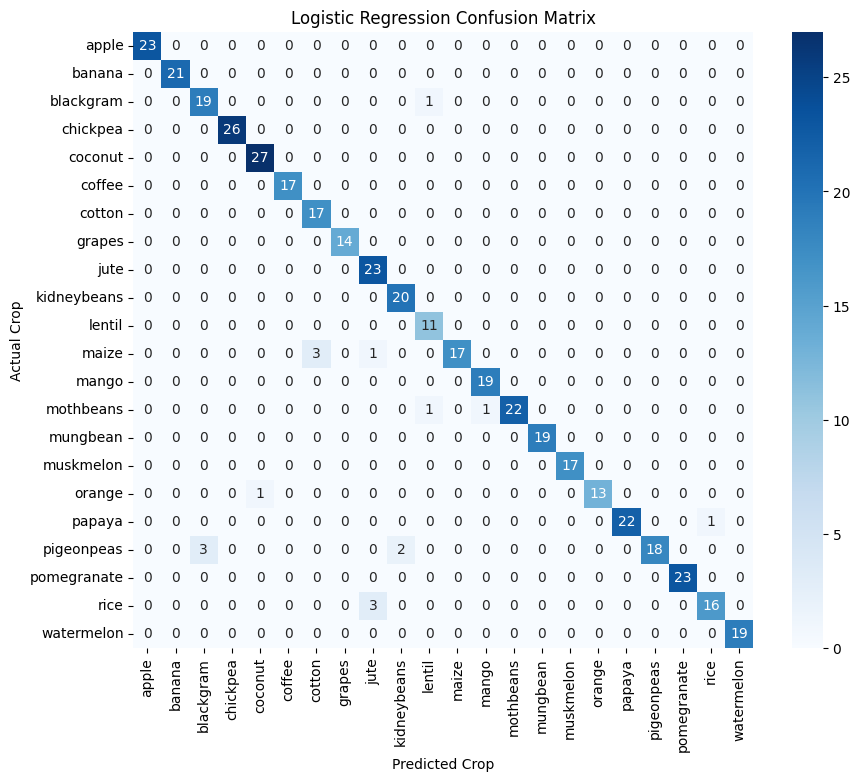

In [23]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

original = pd.read_csv("../data/processed/crop_clean.csv")

le = LabelEncoder()
le.fit(original["label"])

crop_names = le.classes_


plt.figure(figsize=(10,8))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=crop_names,
    yticklabels=crop_names
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()